In [3]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 15
plt.rcParams["axes.labelsize"] = 12

In [4]:
# Load Cleaned Dataset

df = pd.read_csv('/content/movie_metadata.csv')

print("=" * 60)
print("IMDb 5000 MOVIE DATASET - EDA")
print("=" * 60)

print("\nDataset Shape:")
print(df.shape)

print("\nFirst 5 Records:")
display(df.head())

IMDb 5000 MOVIE DATASET - EDA

Dataset Shape:
(5043, 28)

First 5 Records:


,color,director_name,num_critic_for_reviews,duration,director_facebook_likes,actor_3_facebook_likes,actor_2_name,actor_1_facebook_likes,gross,genres,...,num_user_for_reviews,language,country,content_rating,budget,title_year,actor_2_facebook_likes,imdb_score,aspect_ratio,movie_facebook_likes
0,Color,James Cameron,723.0,178.0,0.0,855.0,Joel David Moore,1000.0,760505847.0,Action|Adventure|Fantasy|Sci-Fi,...,3054.0,English,USA,PG-13,237000000.0,2009.0,936.0,7.9,1.78,33000
1,Color,Gore Verbinski,302.0,169.0,563.0,1000.0,Orlando Bloom,40000.0,309404152.0,Action|Adventure|Fantasy,...,1238.0,English,USA,PG-13,300000000.0,2007.0,5000.0,7.1,2.35,0
2,Color,Sam Mendes,602.0,148.0,0.0,161.0,Rory Kinnear,11000.0,200074175.0,Action|Adventure|Thriller,...,994.0,English,UK,PG-13,245000000.0,2015.0,393.0,6.8,2.35,85000
3,Color,Christopher Nolan,813.0,164.0,22000.0,23000.0,Christian Bale,27000.0,448130642.0,Action|Thriller,...,2701.0,English,USA,PG-13,250000000.0,2012.0,23000.0,8.5,2.35,164000
4,NaN,Doug Walker,NaN,NaN,131.0,NaN,Rob Walker,131.0,NaN,Documentary,...,NaN,NaN,NaN,NaN,NaN,NaN,12.0,7.1,NaN,0


In [5]:
# Dataset Information

print("\n" + "=" * 60)
print("DATASET INFORMATION")
print("=" * 60)

print("\nData Types:")
print(df.dtypes)

print("\nDataset Information:")
df.info()


DATASET INFORMATION

Data Types:
color                         object
director_name                 object
num_critic_for_reviews       float64
duration                     float64
director_facebook_likes      float64
actor_3_facebook_likes       float64
actor_2_name                  object
actor_1_facebook_likes       float64
gross                        float64
genres                        object
actor_1_name                  object
movie_title                   object
num_voted_users                int64
cast_total_facebook_likes      int64
actor_3_name                  object
facenumber_in_poster         float64
plot_keywords                 object
movie_imdb_link               object
num_user_for_reviews         float64
language                      object
country                       object
content_rating                object
budget                       float64
title_year                   float64
actor_2_facebook_likes       float64
imdb_score                   float64
aspe

In [6]:
# Descriptive Statistics

print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS")
print("=" * 60)

display(df.describe().T)


DESCRIPTIVE STATISTICS


,count,mean,std,min,25%,50%,75%,max
num_critic_for_reviews,4993.0,1.401943e+02,1.216017e+02,1.00,50.00,110.00,195.00,8.130000e+02
duration,5028.0,1.072011e+02,2.519744e+01,7.00,93.00,103.00,118.00,5.110000e+02
director_facebook_likes,4939.0,6.865092e+02,2.813329e+03,0.00,7.00,49.00,194.50,2.300000e+04
actor_3_facebook_likes,5020.0,6.450098e+02,1.665042e+03,0.00,133.00,371.50,636.00,2.300000e+04
actor_1_facebook_likes,5036.0,6.560047e+03,1.502076e+04,0.00,614.00,988.00,11000.00,6.400000e+05
gross,4159.0,4.846841e+07,6.845299e+07,162.00,5340987.50,25517500.00,62309437.50,7.605058e+08
num_voted_users,5043.0,8.366816e+04,1.384853e+05,5.00,8593.50,34359.00,96309.00,1.689764e+06
cast_total_facebook_likes,5043.0,9.699064e+03,1.816380e+04,0.00,1411.00,3090.00,13756.50,6.567300e+05
facenumber_in_poster,5030.0,1.371173e+00,2.013576e+00,0.00,0.00,1.00,2.00,4.300000e+01
num_user_for_reviews,5022.0,2.727708e+02,3.779829e+02,1.00,65.00,156.00,326.00,5.060000e+03


In [7]:
# Check Missing Values

print("\n" + "=" * 60)
print("MISSING VALUE CHECK")
print("=" * 60)

missing_values = df.isnull().sum()

print(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No missing values found in the cleaned dataset.")


MISSING VALUE CHECK
color                       19
director_name              104
num_critic_for_reviews      50
duration                    15
director_facebook_likes    104
actor_3_facebook_likes      23
actor_2_name                13
actor_1_facebook_likes       7
gross                      884
actor_1_name                 7
actor_3_name                23
facenumber_in_poster        13
plot_keywords              153
num_user_for_reviews        21
language                    14
country                      5
content_rating             303
budget                     492
title_year                 108
actor_2_facebook_likes      13
aspect_ratio               329
dtype: int64


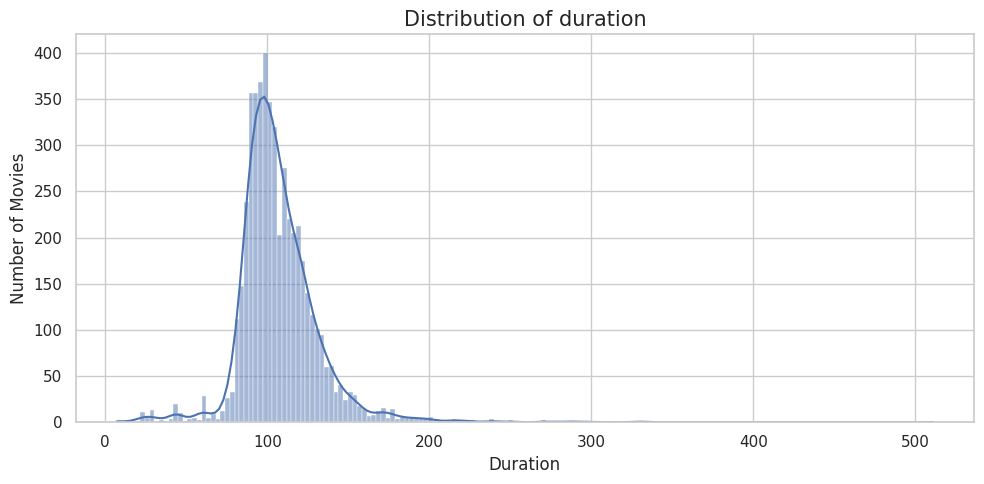

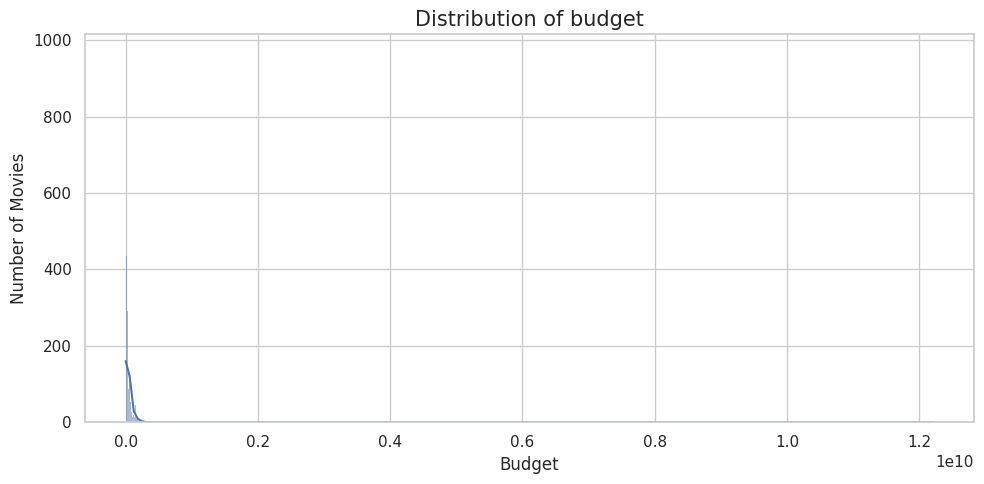

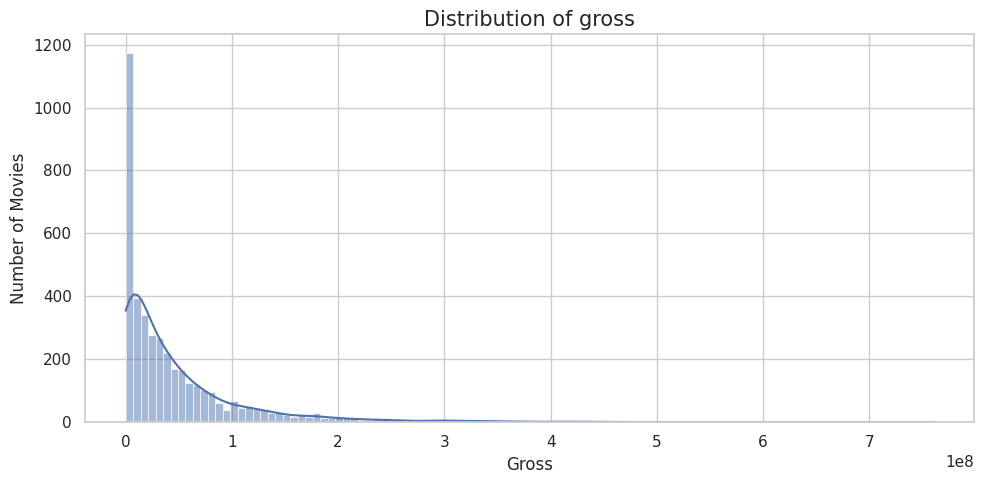

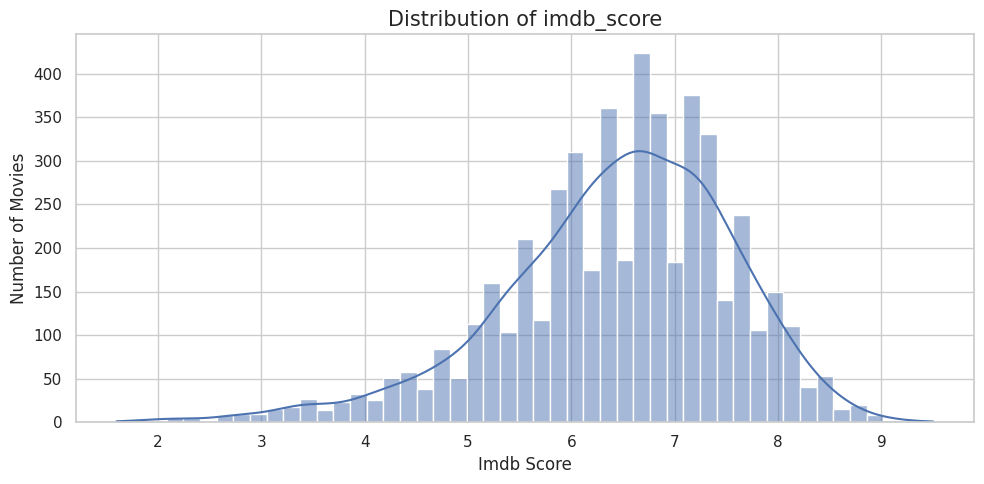

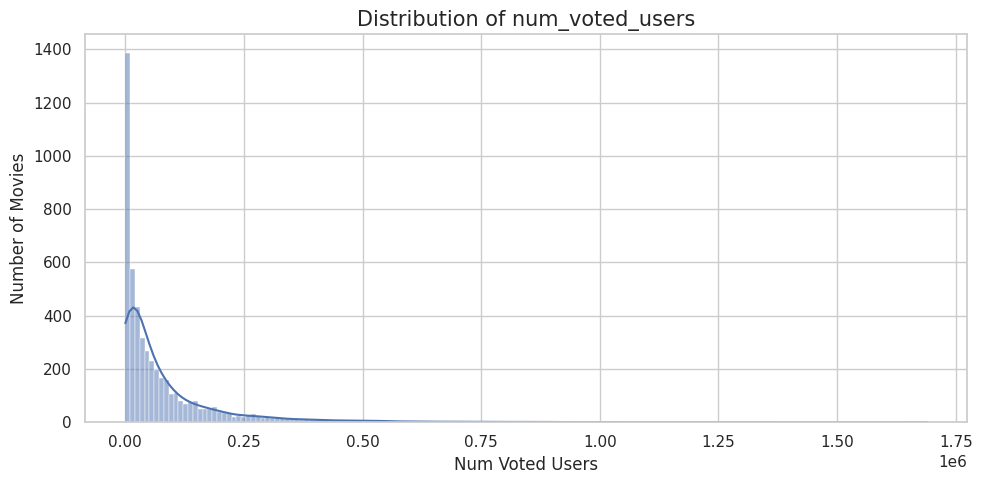

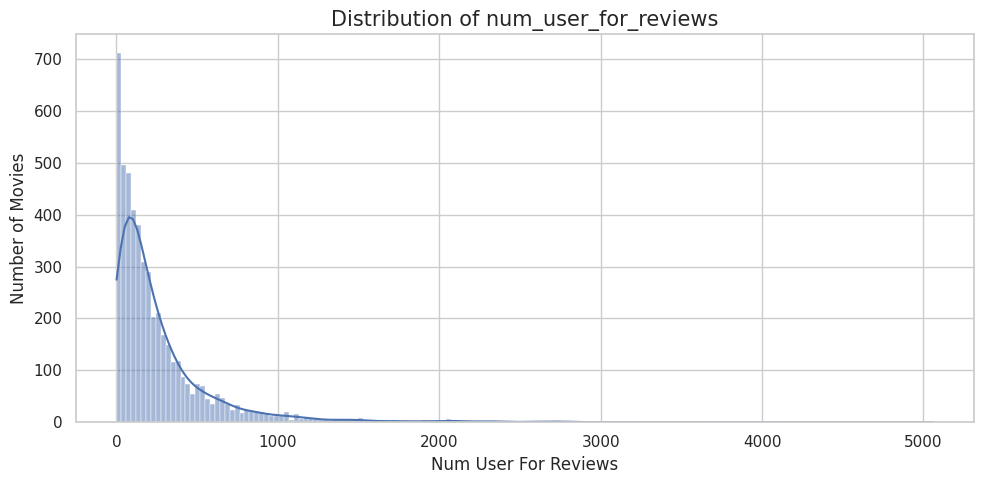

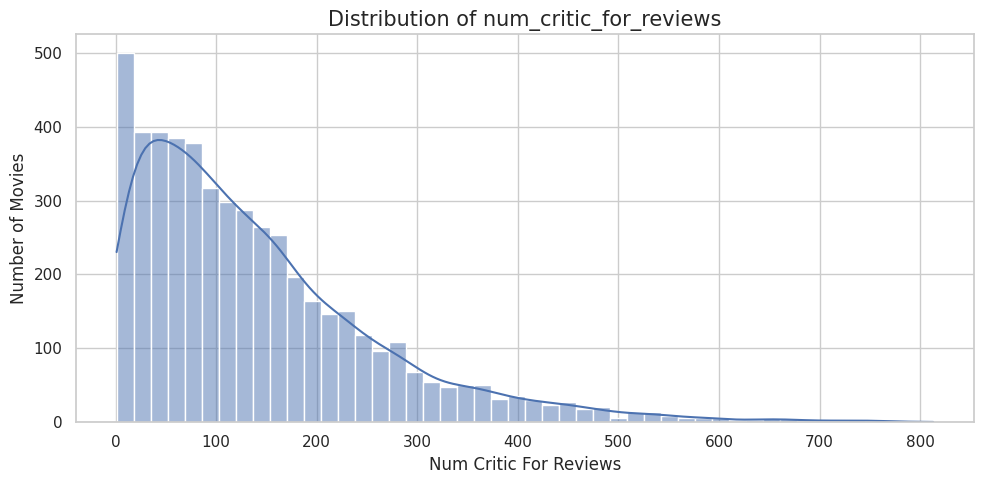

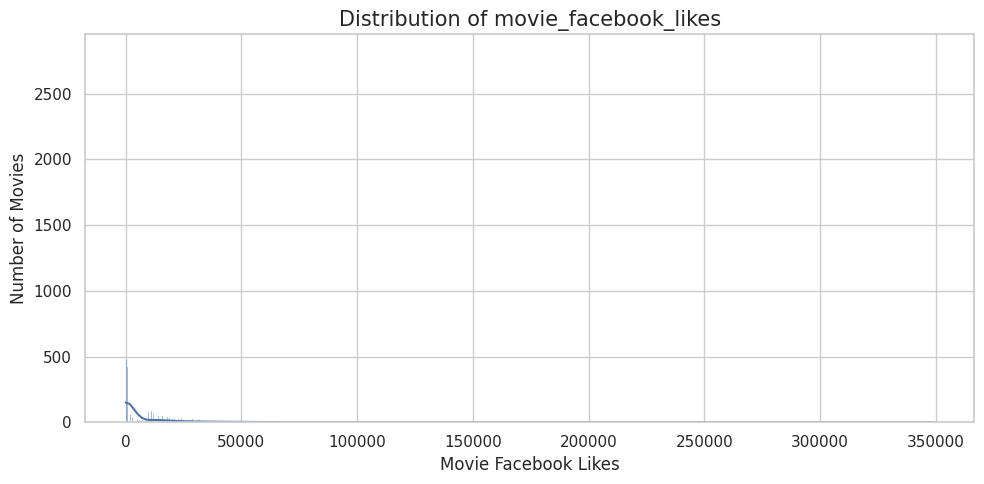

In [8]:
# Numerical Feature Distribution

numerical_columns = [
    'duration',
    'budget',
    'gross',
    'imdb_score',
    'num_voted_users',
    'num_user_for_reviews',
    'num_critic_for_reviews',
    'movie_facebook_likes'
]

numerical_columns = [
    col for col in numerical_columns
    if col in df.columns
]

for column in numerical_columns:

    plt.figure(figsize=(10, 5))

    sns.histplot(
        data=df,
        x=column,
        kde=True
    )

    plt.title(f'Distribution of {column}')
    plt.xlabel(column.replace('_', ' ').title())
    plt.ylabel('Number of Movies')

    plt.tight_layout()
    plt.show()

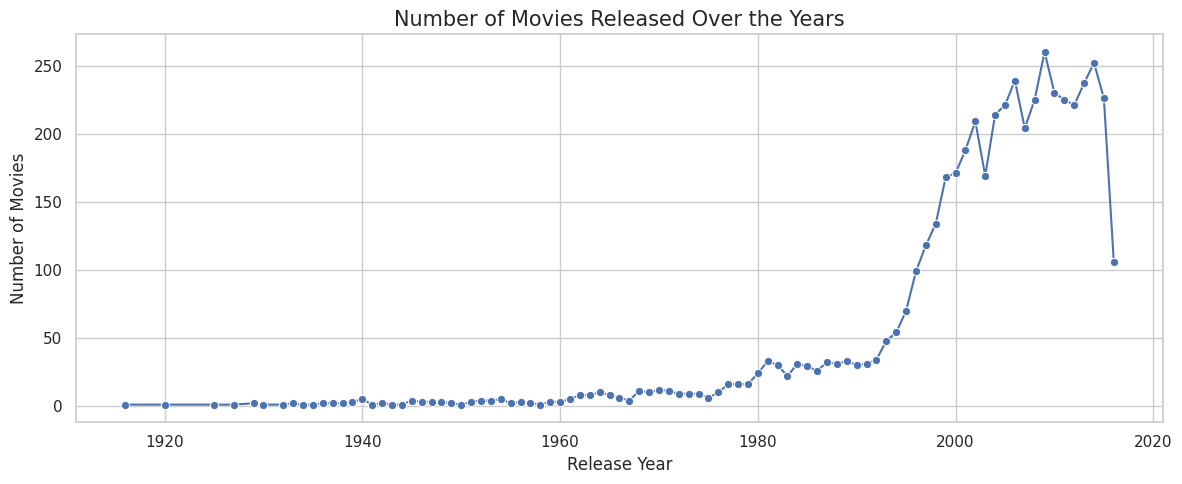

In [9]:
# Movie Release Trend

if 'title_year' in df.columns:

    yearly_movies = (
        df['title_year']
        .value_counts()
        .sort_index()
    )

    plt.figure(figsize=(12, 5))

    sns.lineplot(
        x=yearly_movies.index,
        y=yearly_movies.values,
        marker='o'
    )

    plt.title('Number of Movies Released Over the Years')
    plt.xlabel('Release Year')
    plt.ylabel('Number of Movies')

    plt.tight_layout()
    plt.show()

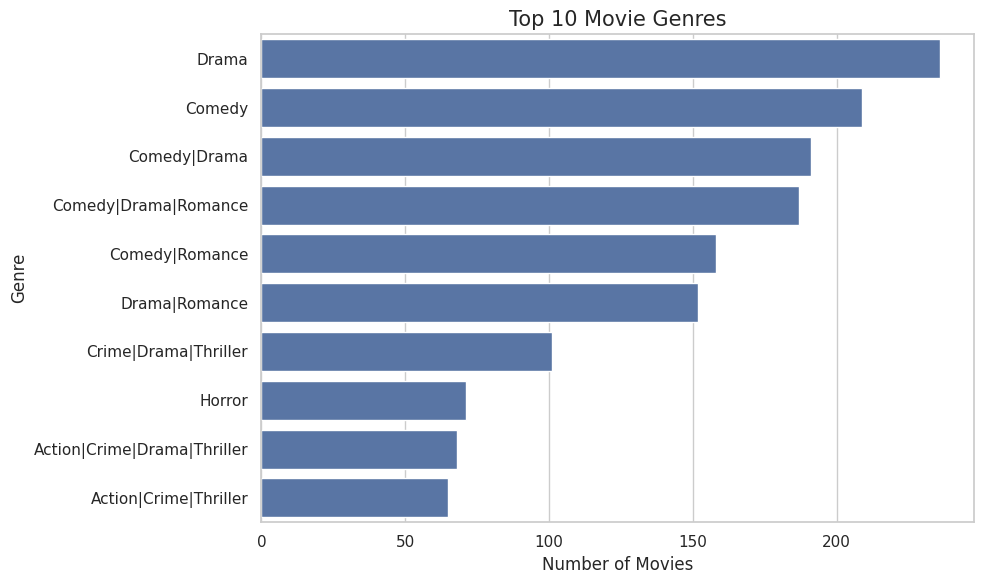

In [10]:
# Genre Distribution

if 'genres' in df.columns:

    genre_counts = (
        df['genres']
        .value_counts()
        .head(10)
    )

    plt.figure(figsize=(10, 6))

    sns.barplot(
        x=genre_counts.values,
        y=genre_counts.index
    )

    plt.title('Top 10 Movie Genres')
    plt.xlabel('Number of Movies')
    plt.ylabel('Genre')

    plt.tight_layout()
    plt.show()

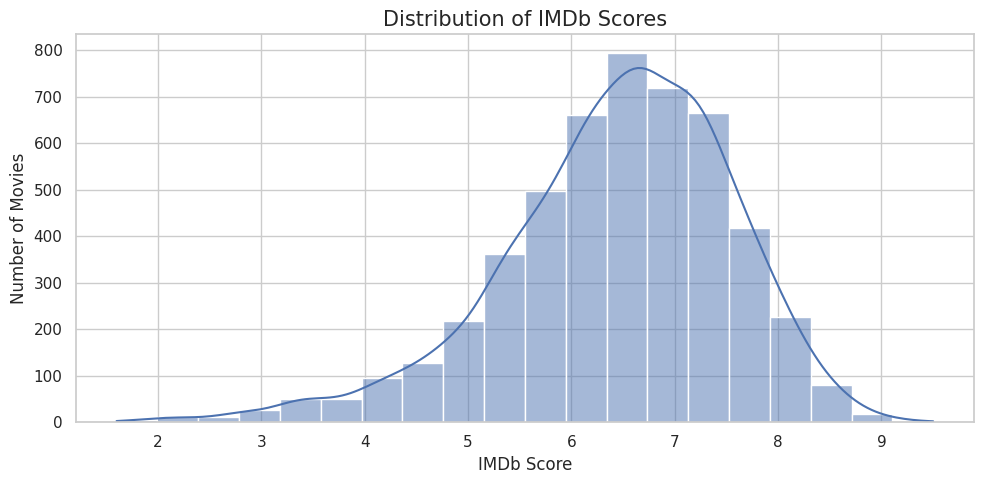

In [11]:
# IMDb Score Distribution

if 'imdb_score' in df.columns:

    plt.figure(figsize=(10, 5))

    sns.histplot(
        data=df,
        x='imdb_score',
        bins=20,
        kde=True
    )

    plt.title('Distribution of IMDb Scores')
    plt.xlabel('IMDb Score')
    plt.ylabel('Number of Movies')

    plt.tight_layout()
    plt.show()

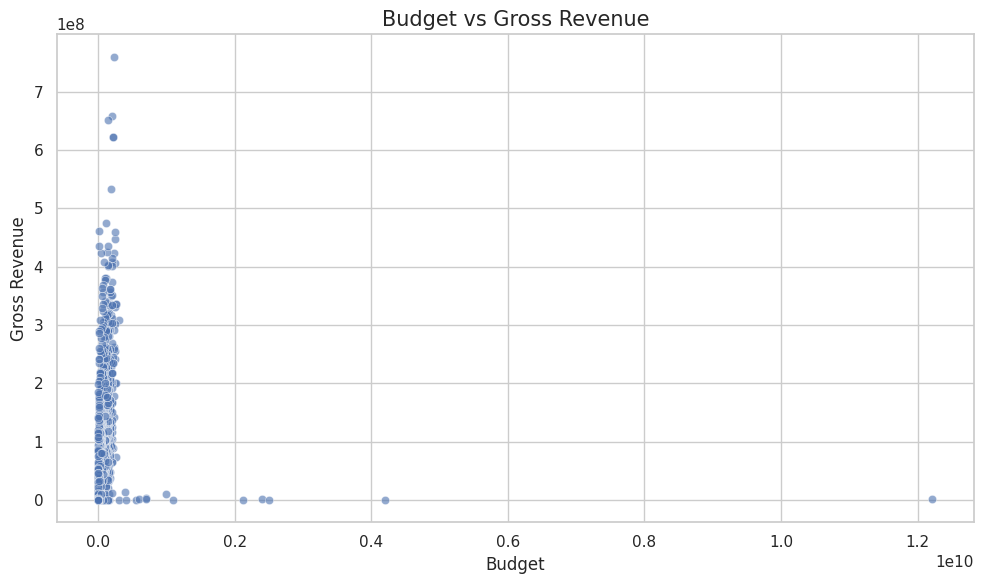

In [12]:
# Budget vs Gross Revenue

if 'budget' in df.columns and 'gross' in df.columns:

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x='budget',
        y='gross',
        alpha=0.6
    )

    plt.title('Budget vs Gross Revenue')
    plt.xlabel('Budget')
    plt.ylabel('Gross Revenue')

    plt.tight_layout()
    plt.show()

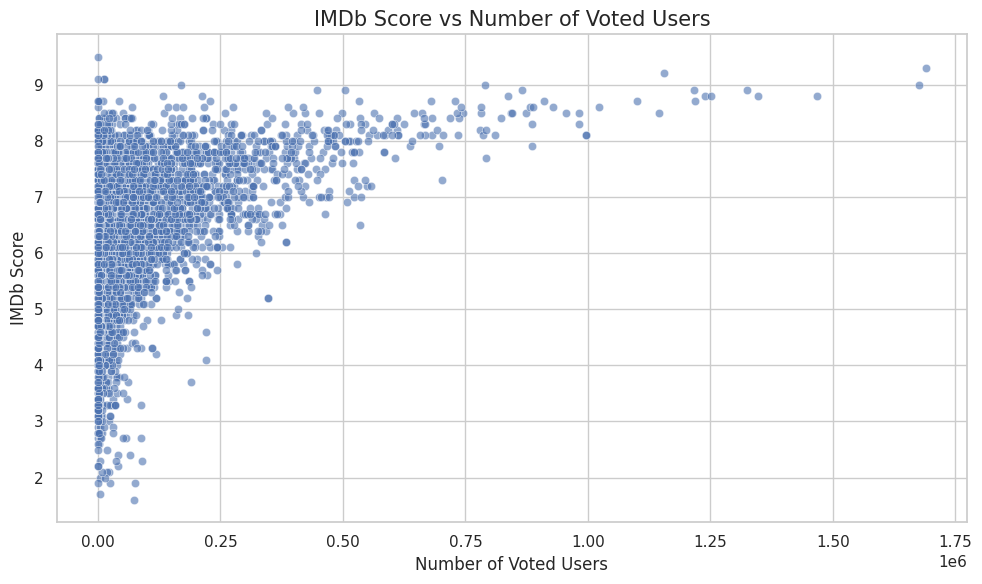

In [13]:
# IMDb Score vs Number of Votes

if 'imdb_score' in df.columns and 'num_voted_users' in df.columns:

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x='num_voted_users',
        y='imdb_score',
        alpha=0.6
    )

    plt.title('IMDb Score vs Number of Voted Users')
    plt.xlabel('Number of Voted Users')
    plt.ylabel('IMDb Score')

    plt.tight_layout()
    plt.show()

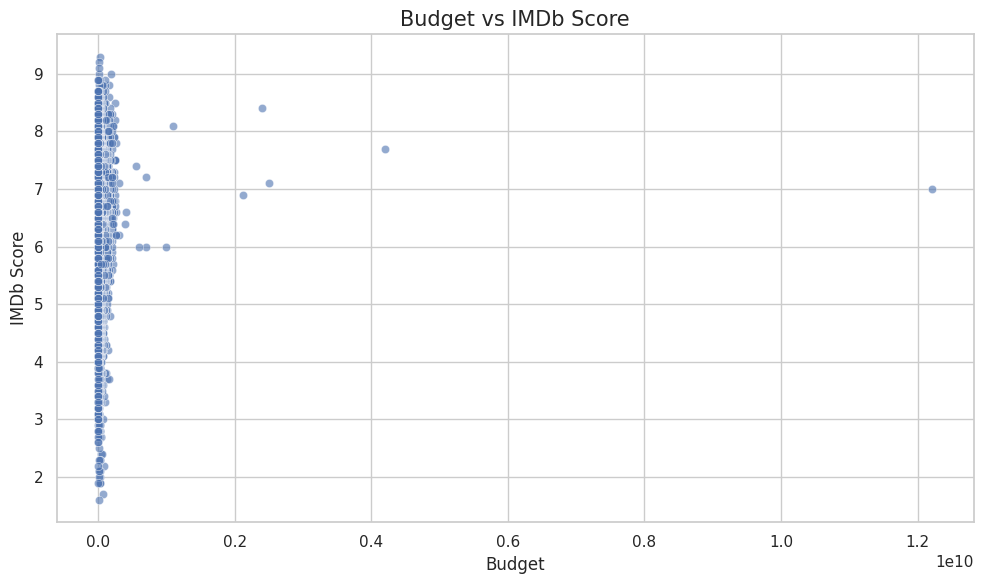

In [14]:
# Budget vs IMDb Score

if 'budget' in df.columns and 'imdb_score' in df.columns:

    plt.figure(figsize=(10, 6))

    sns.scatterplot(
        data=df,
        x='budget',
        y='imdb_score',
        alpha=0.6
    )

    plt.title('Budget vs IMDb Score')
    plt.xlabel('Budget')
    plt.ylabel('IMDb Score')

    plt.tight_layout()
    plt.show()

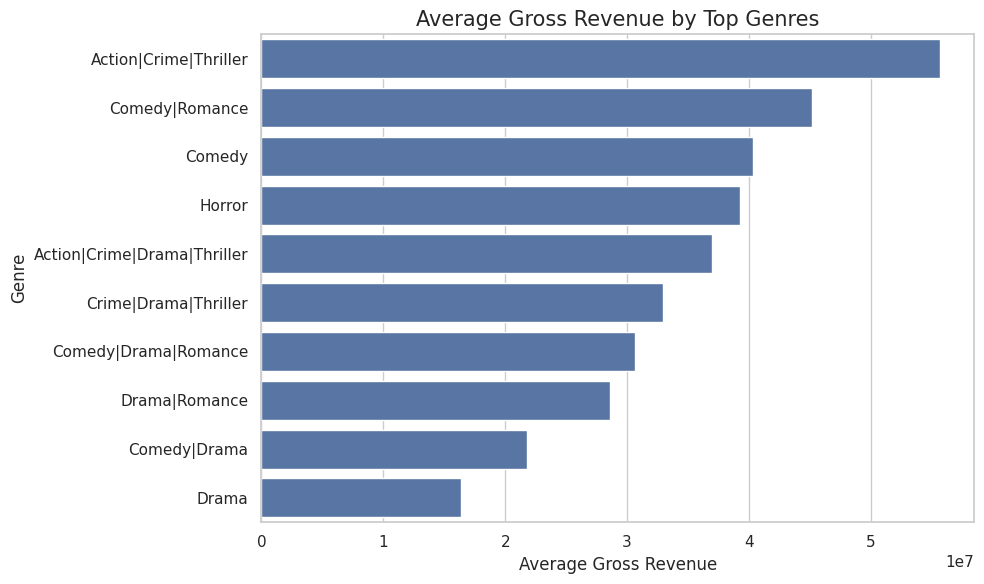

In [15]:
# Gross Revenue by Top Genres

if 'genres' in df.columns and 'gross' in df.columns:

    top_genres = df['genres'].value_counts().head(10).index

    genre_revenue = (
        df[df['genres'].isin(top_genres)]
        .groupby('genres')['gross']
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 6))

    sns.barplot(
        x=genre_revenue.values,
        y=genre_revenue.index
    )

    plt.title('Average Gross Revenue by Top Genres')
    plt.xlabel('Average Gross Revenue')
    plt.ylabel('Genre')

    plt.tight_layout()
    plt.show()

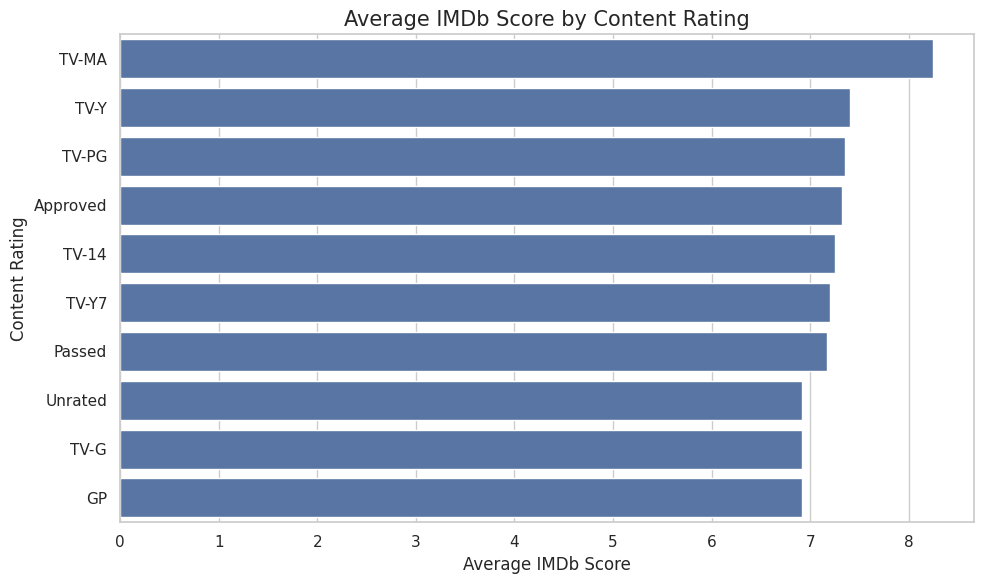

In [16]:
# IMDb Score by Content Rating

if 'content_rating' in df.columns and 'imdb_score' in df.columns:

    rating_score = (
        df.groupby('content_rating')['imdb_score']
        .mean()
        .sort_values(ascending=False)
        .head(10)
    )

    plt.figure(figsize=(10, 6))

    sns.barplot(
        x=rating_score.values,
        y=rating_score.index
    )

    plt.title('Average IMDb Score by Content Rating')
    plt.xlabel('Average IMDb Score')
    plt.ylabel('Content Rating')

    plt.tight_layout()
    plt.show()

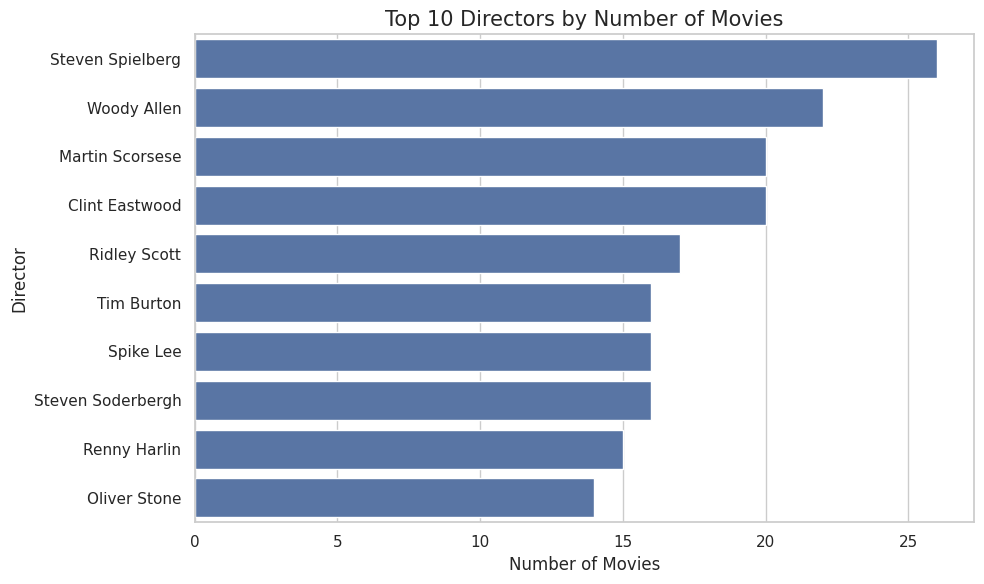

In [17]:
# Top Directors by Number of Movies

if 'director_name' in df.columns:

    top_directors = (
        df['director_name']
        .value_counts()
        .head(10)
    )

    plt.figure(figsize=(10, 6))

    sns.barplot(
        x=top_directors.values,
        y=top_directors.index
    )

    plt.title('Top 10 Directors by Number of Movies')
    plt.xlabel('Number of Movies')
    plt.ylabel('Director')

    plt.tight_layout()
    plt.show()

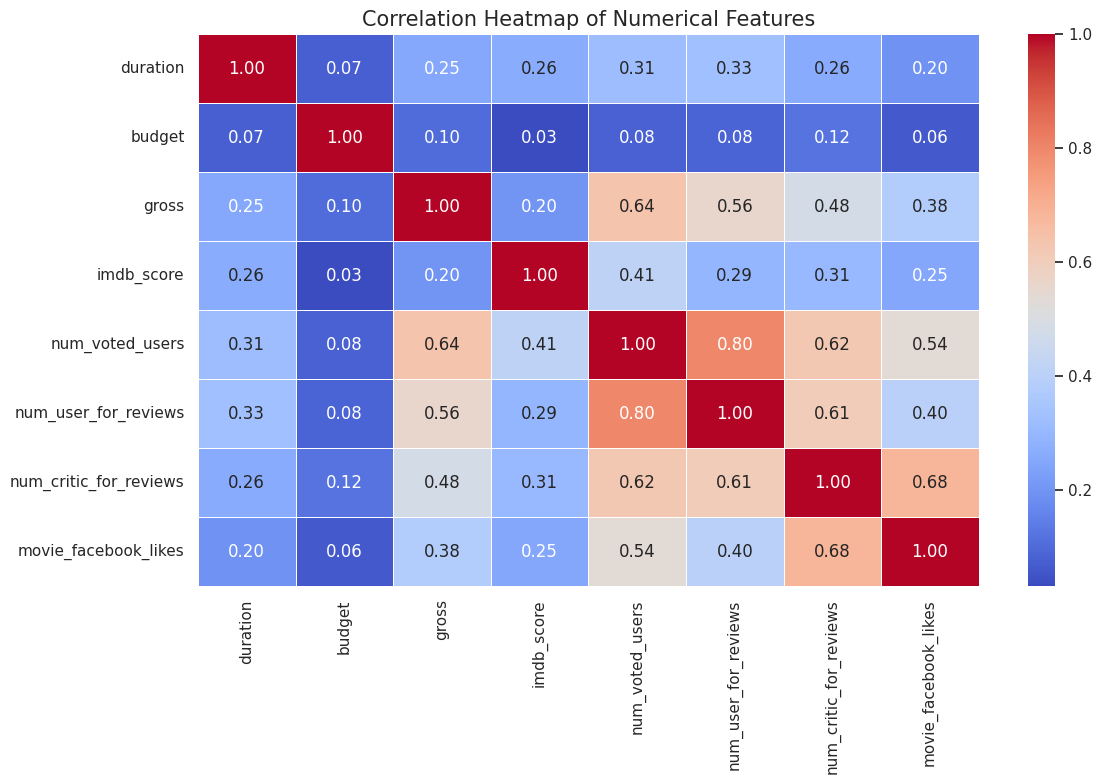

In [18]:
# Correlation Analysis

correlation_columns = [
    'duration',
    'budget',
    'gross',
    'imdb_score',
    'num_voted_users',
    'num_user_for_reviews',
    'num_critic_for_reviews',
    'movie_facebook_likes'
]

correlation_columns = [
    col for col in correlation_columns
    if col in df.columns
]

correlation_matrix = df[correlation_columns].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5
)

plt.title('Correlation Heatmap of Numerical Features')

plt.tight_layout()
plt.show()

In [19]:
# Top Correlations with IMDb Score

if 'imdb_score' in correlation_matrix.columns:

    imdb_correlations = (
        correlation_matrix['imdb_score']
        .sort_values(ascending=False)
    )

    print("\n" + "=" * 60)
    print("CORRELATION WITH IMDb SCORE")
    print("=" * 60)

    print(imdb_correlations)


CORRELATION WITH IMDb SCORE
imdb_score                1.000000
num_voted_users           0.410965
num_critic_for_reviews    0.305303
num_user_for_reviews      0.292475
duration                  0.261662
movie_facebook_likes      0.247049
gross                     0.198021
budget                    0.030688
Name: imdb_score, dtype: float64


In [20]:
# Top Movies by Gross Revenue

if 'movie_title' in df.columns and 'gross' in df.columns:

    top_movies = (
        df[['movie_title', 'gross']]
        .sort_values(by='gross', ascending=False)
        .head(10)
    )

    print("\n" + "=" * 60)
    print("TOP 10 MOVIES BY GROSS REVENUE")
    print("=" * 60)

    display(top_movies)


TOP 10 MOVIES BY GROSS REVENUE


,movie_title,gross
0,Avatar,760505847.0
26,Titanic,658672302.0
29,Jurassic World,652177271.0
17,The Avengers,623279547.0
794,The Avengers,623279547.0
66,The Dark Knight,533316061.0
240,Star Wars: Episode I - The Phantom Menace,474544677.0
3024,Star Wars: Episode IV - A New Hope,460935665.0
8,Avengers: Age of Ultron,458991599.0
3,The Dark Knight Rises,448130642.0


In [21]:
# Top Movies by IMDb Score

if 'movie_title' in df.columns and 'imdb_score' in df.columns:

    top_rated_movies = (
        df[['movie_title', 'imdb_score']]
        .sort_values(by='imdb_score', ascending=False)
        .head(10)
    )

    print("\n" + "=" * 60)
    print("TOP 10 MOVIES BY IMDb SCORE")
    print("=" * 60)

    display(top_rated_movies)


TOP 10 MOVIES BY IMDb SCORE


,movie_title,imdb_score
2765,Towering Inferno,9.5
1937,The Shawshank Redemption,9.3
3466,The Godfather,9.2
3207,Dekalog,9.1
2824,Dekalog,9.1
4409,Kickboxer: Vengeance,9.1
3481,Fargo,9.0
66,The Dark Knight,9.0
2837,The Godfather: Part II,9.0
1874,Schindler's List,8.9


In [22]:
# Final EDA Summary

print("\n" + "=" * 60)
print("EDA COMPLETED SUCCESSFULLY")
print("=" * 60)

print(f"Total Movies Analysed : {df.shape[0]}")
print(f"Total Attributes      : {df.shape[1]}")

print("\nEDA included:")
print("1. Dataset information")
print("2. Descriptive statistics")
print("3. Numerical distributions")
print("4. Movie release trends")
print("5. Genre analysis")
print("6. Budget vs revenue analysis")
print("7. IMDb score analysis")
print("8. Audience engagement analysis")
print("9. Content rating analysis")
print("10. Director analysis")
print("11. Correlation analysis")
print("12. Top movie analysis")


EDA COMPLETED SUCCESSFULLY
Total Movies Analysed : 5043
Total Attributes      : 28

EDA included:
1. Dataset information
2. Descriptive statistics
3. Numerical distributions
4. Movie release trends
5. Genre analysis
6. Budget vs revenue analysis
7. IMDb score analysis
8. Audience engagement analysis
9. Content rating analysis
10. Director analysis
11. Correlation analysis
12. Top movie analysis
